In [14]:
### ANOMALY DETECTION PIPELINE ### 
# Exploration, train/testing, and evaluation on synthetic loan brokerage transaction data

# Statistical layer: Seasonality-aware z-score grouped by hour of day, day of week (volume, velocity, and approval-rate deviations)
# ML layer: Isolation Forest trained on clean historical window (multi-dimensional anomalies)

In [15]:
# Train/test split: 
# Baselines and IF models trained on the first 75 days. Anomaly detection runs on the final 15 days.
# This prevents the anomaly from biasing its own seasonal mean, to mirror production

In [16]:
import os, random
from dataclasses import dataclass, field
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
os.makedirs('../data', exist_ok=True)

# Domain config
START        = datetime(2024, 10, 1)
END          = datetime(2024, 12, 30)
STATES       = ['CA', 'TX', 'FL', 'NY', 'WA', 'IL', 'GA', 'AZ', 'CO', 'OH']
PRODUCTS     = ['mortgage', 'auto_loan', 'personal_loan', 'credit_card']
STATE_W      = [0.15, 0.14, 0.12, 0.12, 0.08, 0.08, 0.08, 0.08, 0.07, 0.08]
PRODUCT_W    = [0.20, 0.30, 0.25, 0.25]
APPROVAL_R   = {'mortgage': 0.72, 'auto_loan': 0.85,
                'personal_loan': 0.78, 'credit_card': 0.88}
N_CUSTOMERS  = 300

# Relevant thresholds
ZSCORE_THRESH   = 3.0
HIGH_THRESH     = 4.5       # single-layer signal surfaced only above this
ML_THRESH       = -0.15     # IF decision score below this = anomaly
VELOCITY_THRESH = 2.0       # 200 % hour-over-hour change
CONTAMINATION   = 0.025     # anticipated ratio of anomalous activity
MIN_VOLUME      = 5         # skip statistical layer below this hourly count

# Isolation forest feats
BASE_IF_FEATURES = ['volume_z_score', 'velocity_pct', 'hour_of_day', 'day_of_week']

In [17]:
## GENERATE SYNTHETIC DATA
# 1000 total transactions over 90 days; 65 injected anomalies

In [18]:
# Hour-of-day sampling weights (business hours heavier)
HOUR_W = np.array([0.3, 0.2, 0.1, 0.1, 0.1, 0.2, 0.5, 1.0, 2.5, 3.0, 3.5, 3.5, 3.0, 3.5, 3.0, 2.5, 2.0, 1.5, 1.0, 0.7, 0.5, 0.4, 0.4, 0.3])
HOUR_W /= HOUR_W.sum()

rng = np.random.default_rng(42)
n_base = 935

# Base transactions (Oct 1 – Dec 29)
day_offsets = rng.integers(0, 90, size=n_base)
hours = rng.choice(24, size=n_base, p=HOUR_W)
minutes = rng.integers(0, 60, size=n_base)
dates = [START + timedelta(days=int(d), hours=int(h), minutes=int(m)) for d, h, m in zip(day_offsets, hours, minutes)]
states_col = rng.choice(STATES,    size=n_base, p=STATE_W)
products_col = rng.choice(PRODUCTS,  size=n_base, p=PRODUCT_W)
is_new_col = rng.random(n_base) < 0.20
cust_ids = [f"C{rng.integers(1, N_CUSTOMERS + 1):04d}" for _ in range(n_base)]
statuses = ['approved' if rng.random() < APPROVAL_R[p] else 'denied' for p in products_col]

base_df = pd.DataFrame({
    'date': dates,
    'transaction_id': [f"T{i+1:06d}" for i in range(n_base)],
    'customer_id': cust_ids,
    'product_type': products_col,
    'state': states_col,
    'is_new_customer': is_new_col,
    'transaction_status': statuses,
    'is_injected': False,
    'anomaly_label': '',
})

In [19]:
def _make_row(idx, ts, state, product, is_new, status, label):
    return {
        'date': ts,
        'transaction_id': f"INJ_{idx:03d}",
        'customer_id': f"C{rng.integers(1, N_CUSTOMERS + 1):04d}",
        'product_type': product, 
        'state': state,
        'is_new_customer': is_new, 
        'transaction_status': status,
        'is_injected': True, 
        'anomaly_label': label,
    }

In [ ]:
# INJECT ANOMALIES - all placed in the scoring window (Dec 14-29)
# Dates chosen so the training window totally clean.

injected = []

# A1 - Volume spike: TX, 2024-12-17 14:xx (Tuesday, scoring window)
for i in range(25):
    p  = rng.choice(PRODUCTS)
    ts = datetime(2024, 12, 17, 14, int(rng.integers(0, 60)), int(rng.integers(0, 60)))
    st = 'approved' if rng.random() < APPROVAL_R[p] else 'denied'
    injected.append(_make_row(i, ts, 'TX', p, rng.random() < 0.20, st, 'A1_volume_spike_TX'))

# A2 - Approval-rate crash: CA, 2024-12-18 10:xx (Wednesday, 80 % denied)
for i in range(20):
    ts = datetime(2024, 12, 18, 10, int(rng.integers(0, 60)), int(rng.integers(0, 60)))
    st = 'denied' if rng.random() < 0.80 else 'approved'
    injected.append(_make_row(25 + i, ts, 'CA', 'mortgage', rng.random() < 0.40, st,
                              'A2_approval_rate_drop_CA'))

# A3 - New-customer spike: 2024-12-19 11:xx (Thursday, +20 new-customer rows)
for i in range(20):
    p  = rng.choice(['personal_loan', 'credit_card'])
    ts = datetime(2024, 12, 19, 11, int(rng.integers(0, 60)), int(rng.integers(0, 60)))
    st = 'approved' if rng.random() < 0.78 else 'denied'
    injected.append(_make_row(45 + i, ts, rng.choice(STATES), p, True, st,
                              'A3_volume_spike_new_customers'))


# Save
df = pd.concat([base_df, pd.DataFrame(injected)], ignore_index=True)
df = df.sort_values('date').reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'])

df.to_csv('../data/transactions_synthetic.csv', index=False)
print(f"Saved  ../data/transactions_synthetic.csv")
print(f"Total  : {len(df):,} rows")
print(f"Inject : {df['is_injected'].sum()} rows  {df['anomaly_label'].value_counts().to_dict()}")
df.head(6)

Saved  ../data/transactions_synthetic.csv
Total  : 1,000 rows
Inject : 65 rows  {'': 935, 'A1_volume_spike_TX': 25, 'A2_approval_rate_drop_CA': 20, 'A3_volume_spike_new_customers': 20}


,date,transaction_id,customer_id,product_type,state,is_new_customer,transaction_status,is_injected,anomaly_label
0,2024-10-01 00:07:00,T000846,C0194,auto_loan,TX,False,denied,False,
1,2024-10-01 09:30:00,T000901,C0175,mortgage,TX,False,denied,False,
2,2024-10-01 09:56:00,T000381,C0274,mortgage,WA,False,approved,False,
3,2024-10-01 10:22:00,T000303,C0252,personal_loan,NY,True,approved,False,
4,2024-10-01 11:58:00,T000465,C0154,mortgage,NY,False,approved,False,
5,2024-10-01 12:34:00,T000707,C0220,personal_loan,GA,False,denied,False,


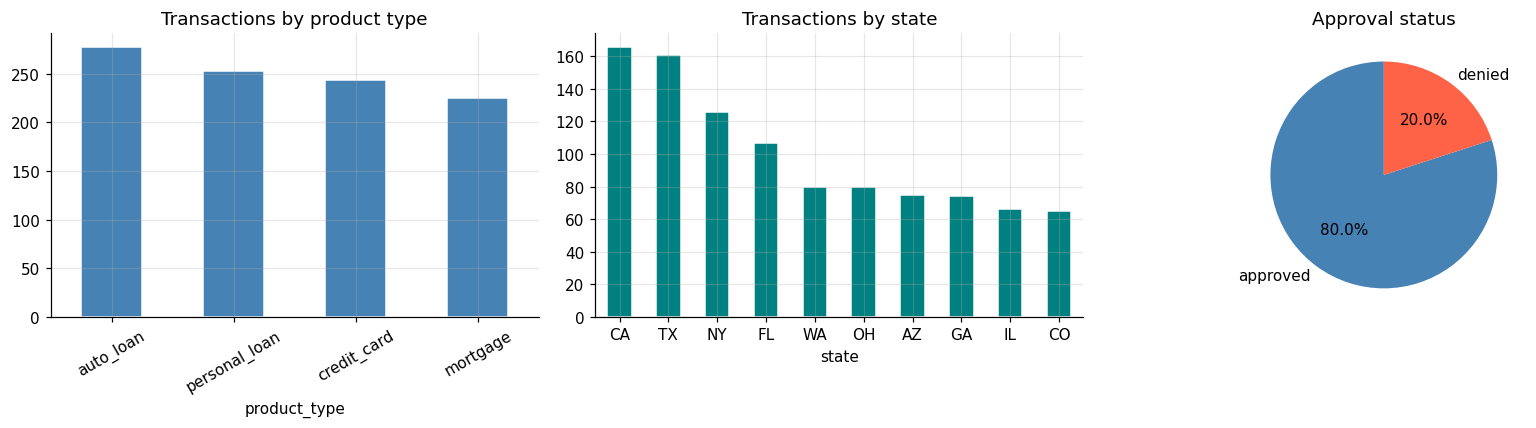

Approval rate by product:
product_type
auto_loan       0.860
credit_card     0.889
mortgage        0.622
personal_loan   0.806
Name: transaction_status, dtype: float64


In [21]:
# QUICK EDA

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['product_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white', rot=30)
axes[0].set_title('Transactions by product type')

df['state'].value_counts().plot(
    kind='bar', ax=axes[1], color='teal', edgecolor='white', rot=0)
axes[1].set_title('Transactions by state')

df['transaction_status'].value_counts().plot(
    kind='pie', ax=axes[2], autopct='%1.1f%%',
    colors=['steelblue', 'tomato'], startangle=90)
axes[2].set_ylabel('')
axes[2].set_title('Approval status')

plt.tight_layout()
plt.show()

print("Approval rate by product:")
print(df.groupby('product_type')['transaction_status']
        .apply(lambda x: (x == 'approved').mean()).round(3))

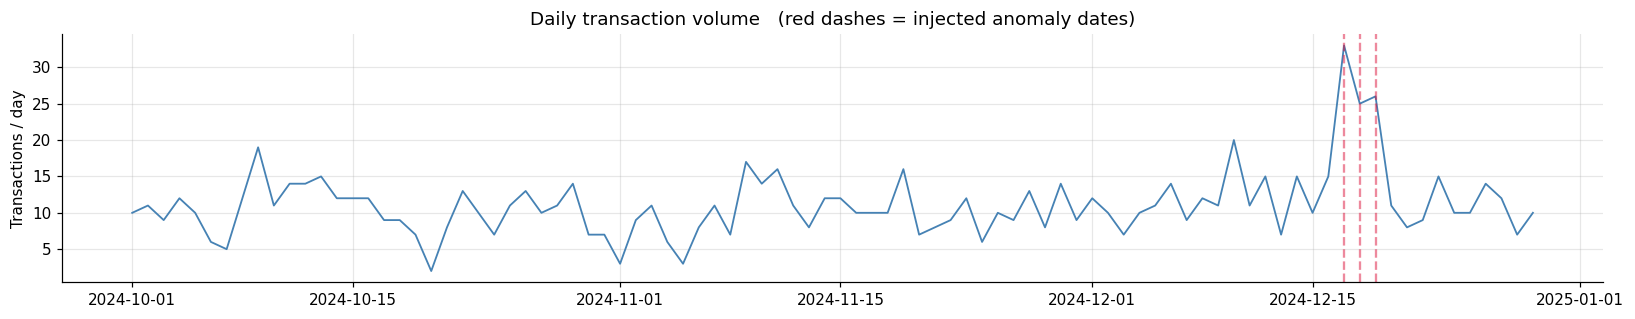

In [22]:
# Daily transaction volume

daily = df.groupby(df['date'].dt.date).size().reset_index(name='count')
daily['date'] = pd.to_datetime(daily['date'])

anomaly_dates = df.loc[df['is_injected'], 'date'].dt.normalize().unique()

plt.figure(figsize=(15, 3))
plt.plot(daily['date'], daily['count'], color='steelblue', linewidth=1.2)
for d in anomaly_dates:
    plt.axvline(d, color='crimson', alpha=0.5, linewidth=1.5, linestyle='--')
plt.title('Daily transaction volume   (red dashes = injected anomaly dates)')
plt.ylabel('Transactions / day')
plt.tight_layout()
plt.show()

In [23]:
# FEATURE ENGINEERING (hourly; cleaned, function form for pipeline)

In [24]:
# Aggregate raw transaction rows to hourly counts per group slice
def aggregate_hourly(df: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    d = df.copy()

    d['hour_bucket'] = d['date'].dt.floor('h')
    by = ['hour_bucket'] + (group_cols or [])

    agg = d.groupby(by).agg(
        volume = ('transaction_id', 'count'),
        n_approved = ('transaction_status', lambda x: (x == 'approved').sum()),
        is_injected = ('is_injected', 'any'),
        anomaly_label = ('anomaly_label', lambda x: ','.join(x[x != ''].unique())),
    ).reset_index()

    agg['approval_rate'] = agg['n_approved'] / agg['volume']
    agg['hour_of_day']   = agg['hour_bucket'].dt.hour
    agg['day_of_week']   = agg['hour_bucket'].dt.dayofweek  # 0 = Monday

    return agg

In [25]:
# Hour-over-hour volume delta
def compute_velocity(agg: pd.DataFrame, group_cols=None) -> pd.DataFrame:
    agg = agg.sort_values(['hour_bucket'] + (group_cols or []))
    
    if group_cols:
        agg['velocity'] = agg.groupby(group_cols)['volume'].diff()
        agg['velocity_pct'] = agg['velocity'] / agg.groupby(group_cols)['volume'].shift(1)

    else:
        agg['velocity'] = agg['volume'].diff()
        agg['velocity_pct'] = agg['velocity'] / agg['volume'].shift(1) #

    agg['velocity_pct'] = agg['velocity_pct'].fillna(0).clip(-5, 5)
    
    return agg

In [26]:
# Compute seasonal mean/std from 'source_agg' and apply to 'agg'.
def compute_seasonal_baseline(
    agg: pd.DataFrame, 
    value_col: str, 
    group_cols=None,
    min_samples: int = 4, 
    source_agg=None,
) -> pd.DataFrame:
    
    source = source_agg if source_agg is not None else agg
    bucket_cols = (group_cols or []) + ['hour_of_day', 'day_of_week']

    # Primary: stats per (group_value, hour_of_day, day_of_week)
    stats = (source.groupby(bucket_cols)[value_col].agg(s_mean='mean', s_std='std', n='count').reset_index())

    stats.rename(columns={
        's_mean': f'{value_col}_seasonal_mean',
        's_std': f'{value_col}_seasonal_std',
        'n': f'{value_col}_n_samples',
    }, inplace=True)

    stats[f'{value_col}_seasonal_std'] = (stats[f'{value_col}_seasonal_std'].fillna(1.0).clip(lower=0.5))
    stats[f'{value_col}_low_sample'] = (stats[f'{value_col}_n_samples'] < min_samples)

    # Fallback: cross-group baseline by (hour_of_day, day_of_week) only
    fallback = (
        source.groupby(['hour_of_day', 'day_of_week'])[value_col]
              .agg(fb_mean='mean', fb_std='std')
              .reset_index()
    )
    fallback['fb_std'] = fallback['fb_std'].fillna(1.0).clip(lower=0.5)

    agg = agg.merge(stats, on=bucket_cols, how='left')
    agg = agg.merge(fallback, on=['hour_of_day', 'day_of_week'], how='left')

    # Fill missing group-level stats with cross-group fallback
    mask = agg[f'{value_col}_seasonal_mean'].isna()
    agg.loc[mask, f'{value_col}_seasonal_mean'] = agg.loc[mask, 'fb_mean']
    agg.loc[mask, f'{value_col}_seasonal_std']  = agg.loc[mask, 'fb_std']
    agg.drop(columns=['fb_mean', 'fb_std'], inplace=True)

    agg[f'{value_col}_z_score'] = ((agg[value_col] - agg[f'{value_col}_seasonal_mean']) / agg[f'{value_col}_seasonal_std'])


    return agg

In [ ]:
# Build hourly feature aggregates for train and score windows separately.
def build_features(train_df: pd.DataFrame, score_df: pd.DataFrame, group_type: str, group_cols=None):

    train_agg = aggregate_hourly(train_df, group_cols)
    score_agg = aggregate_hourly(score_df, group_cols)

    train_agg = compute_velocity(train_agg, group_cols)
    score_agg = compute_velocity(score_agg, group_cols)

    # Train: self-referential baseline (training data is clean)
    train_agg = compute_seasonal_baseline(train_agg, 'volume', group_cols)

    # Score: baseline from training data only - anomaly cannot bias its own mean
    score_agg = compute_seasonal_baseline(score_agg, 'volume', group_cols, source_agg=train_agg)

    if group_type in ('state', 'product_type', 'overall'):
        train_agg = compute_seasonal_baseline(train_agg, 'approval_rate', group_cols)
        score_agg = compute_seasonal_baseline(score_agg, 'approval_rate', group_cols, source_agg=train_agg)

    train_agg['group_type'] = group_type
    score_agg['group_type'] = group_type

    
    return train_agg, score_agg

In [28]:
# TRAINING

In [29]:
# Training window : Oct 1  – Dec 13  (75 days, clean)
# Scoring  window : Dec 14 – Dec 29  (15 days, injected anomalies)
TRAIN_END = pd.Timestamp('2024-12-14')

df_train = df[df['date'] <  TRAIN_END].copy()
df_score = df[df['date'] >= TRAIN_END].copy()

print(f"Training window : {df_train['date'].min().date()} → {df_train['date'].max().date()}  "
      f"({len(df_train):,} rows, injected={df_train['is_injected'].sum()})")
print(f"Scoring  window : {df_score['date'].min().date()} → {df_score['date'].max().date()}  "
      f"({len(df_score):,} rows, injected={df_score['is_injected'].sum()})")

Training window : 2024-10-01 → 2024-12-13  (770 rows, injected=0)
Scoring  window : 2024-12-14 → 2024-12-29  (230 rows, injected=65)


In [30]:
SLICES = {
    'overall': {'group_cols': None},
    'state': {'group_cols': ['state']},
    'product_type': {'group_cols': ['product_type']},
    'transaction_status': {'group_cols': ['transaction_status']},
    'new_customer': {'group_cols': ['is_new_customer']},
}

In [ ]:
train_data = {} # clean history - used to fit IF models
slice_data = {} # scoring window - anomaly detection runs here

for name, cfg in SLICES.items():
    t_agg, s_agg     = build_features(df_train, df_score, name, cfg['group_cols'])
    train_data[name] = t_agg
    slice_data[name] = s_agg

print('\nHourly aggregates per slice:')

for name in SLICES:
    t, s = train_data[name], slice_data[name]
    print(f"  {name:20s}  train_rows={len(t):4d}  "
          f"score_rows={len(s):4d}  "
          f"score_injected={s['is_injected'].sum()}")

print('\nScoring window - state slice (injected rows only):')

cols = ['hour_bucket', 'state', 'volume', 'approval_rate', 'volume_z_score', 'velocity_pct', 'is_injected', 'anomaly_label']
slice_data['state'][slice_data['state']['is_injected']][cols]


Hourly aggregates per slice:
  overall               train_rows= 550  score_rows= 117  score_injected=3
  state                 train_rows= 739  score_rows= 172  score_injected=11
  product_type          train_rows= 716  score_rows= 151  score_injected=7
  transaction_status    train_rows= 598  score_rows= 136  score_injected=6
  new_customer          train_rows= 626  score_rows= 133  score_injected=5

Scoring window — state slice (injected rows only):


,hour_bucket,state,volume,approval_rate,volume_z_score,velocity_pct,is_injected,anomaly_label
44,2024-12-17 14:00:00,TX,25,0.840,48.000,5.000,True,A1_volume_spike_TX
47,2024-12-18 10:00:00,CA,20,0.100,19.000,5.000,True,A2_approval_rate_drop_CA
53,2024-12-19 11:00:00,AZ,2,1.000,2.000,1.000,True,A3_volume_spike_new_customers
54,2024-12-19 11:00:00,CA,4,0.750,6.000,3.000,True,A3_volume_spike_new_customers
55,2024-12-19 11:00:00,CO,3,0.333,4.000,2.000,True,A3_volume_spike_new_customers
56,2024-12-19 11:00:00,FL,1,0.000,0.000,0.000,True,A3_volume_spike_new_customers
57,2024-12-19 11:00:00,IL,1,1.000,0.000,0.000,True,A3_volume_spike_new_customers
58,2024-12-19 11:00:00,NY,1,1.000,0.000,0.000,True,A3_volume_spike_new_customers
59,2024-12-19 11:00:00,OH,1,1.000,0.000,0.000,True,A3_volume_spike_new_customers
60,2024-12-19 11:00:00,TX,4,0.500,6.000,3.000,True,A3_volume_spike_new_customers


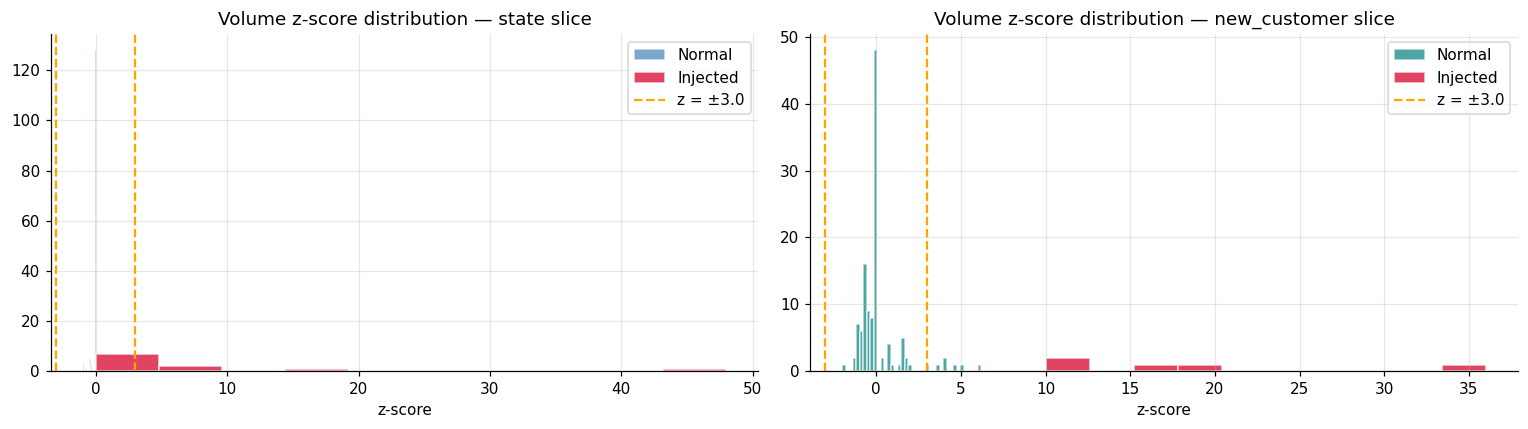

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Z-score distribution - state slice
sd = slice_data['state']
normal  = sd.loc[~sd['is_injected'], 'volume_z_score'].dropna()
anomaly = sd.loc[ sd['is_injected'], 'volume_z_score'].dropna()

axes[0].hist(normal,  bins=40, color='steelblue', alpha=0.7, label='Normal', edgecolor='white')
axes[0].hist(anomaly, bins=10, color='crimson',   alpha=0.8, label='Injected', edgecolor='white')
axes[0].axvline( ZSCORE_THRESH, color='orange', linestyle='--', label=f'z = ±{ZSCORE_THRESH}')
axes[0].axvline(-ZSCORE_THRESH, color='orange', linestyle='--')
axes[0].set_title('Volume z-score distribution - state slice')
axes[0].set_xlabel('z-score')
axes[0].legend()

# Same for new_customer slice
nc = slice_data['new_customer']
normal_nc  = nc.loc[~nc['is_injected'], 'volume_z_score'].dropna()
anomaly_nc = nc.loc[ nc['is_injected'], 'volume_z_score'].dropna()

axes[1].hist(normal_nc,  bins=40, color='teal',    alpha=0.7, label='Normal', edgecolor='white')
axes[1].hist(anomaly_nc, bins=10, color='crimson',  alpha=0.8, label='Injected', edgecolor='white')
axes[1].axvline( ZSCORE_THRESH, color='orange', linestyle='--', label=f'z = ±{ZSCORE_THRESH}')
axes[1].axvline(-ZSCORE_THRESH, color='orange', linestyle='--')
axes[1].set_title('Volume z-score distribution - new_customer slice')
axes[1].set_xlabel('z-score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [33]:
# MODEL TRAINING

In [34]:
# One model per slice; normalized features
def train_isolation_forest(agg, features, contamination=CONTAMINATION, seed=42):
    X_raw = agg[features].fillna(0).values
    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    model = IsolationForest(
        contamination=contamination,
        n_estimators=200,
        random_state=seed,
    )
    model.fit(X)

    return model, scaler

In [ ]:
# Scoring
models = {}
print(f"{'Slice':20s}  {'Train':>6}  {'Score':>6}  {'Feats':>5}  {'IF flagged':>12}  {'%':>6}")
print('-' * 70)

for name, cfg in SLICES.items():
    features = BASE_IF_FEATURES.copy()
    if 'approval_rate_z_score' in train_data[name].columns:
        features.append('approval_rate_z_score')

    # Fit on clean training window
    model, scaler = train_isolation_forest(train_data[name], features)

    # Score the monitoring (scoring) window - anomaly threshold from training distribution
    X_score = scaler.transform(slice_data[name][features].fillna(0).values)
    preds = model.predict(X_score) # -1 = anomaly
    scores = model.decision_function(X_score) # lower = more anomalous

    slice_data[name]['if_flag'] = preds
    slice_data[name]['if_score'] = scores
    models[name] = (model, scaler, features)

    n_flagged = (preds == -1).sum()
    t_rows = len(train_data[name])
    s_rows = len(slice_data[name])
    print(f"{name:20s}  {t_rows:>6}  {s_rows:>6}  {len(features):>5}  "f"{n_flagged:>12}  {100*n_flagged/s_rows:>5.1f}")

Slice                  Train   Score  Feats    IF flagged       %
----------------------------------------------------------------------
overall                  550     117      5            13   11.1
state                    739     172      5            16    9.3
product_type             716     151      5            22   14.6
transaction_status       598     136      4            12    8.8
new_customer             626     133      4            10    7.5


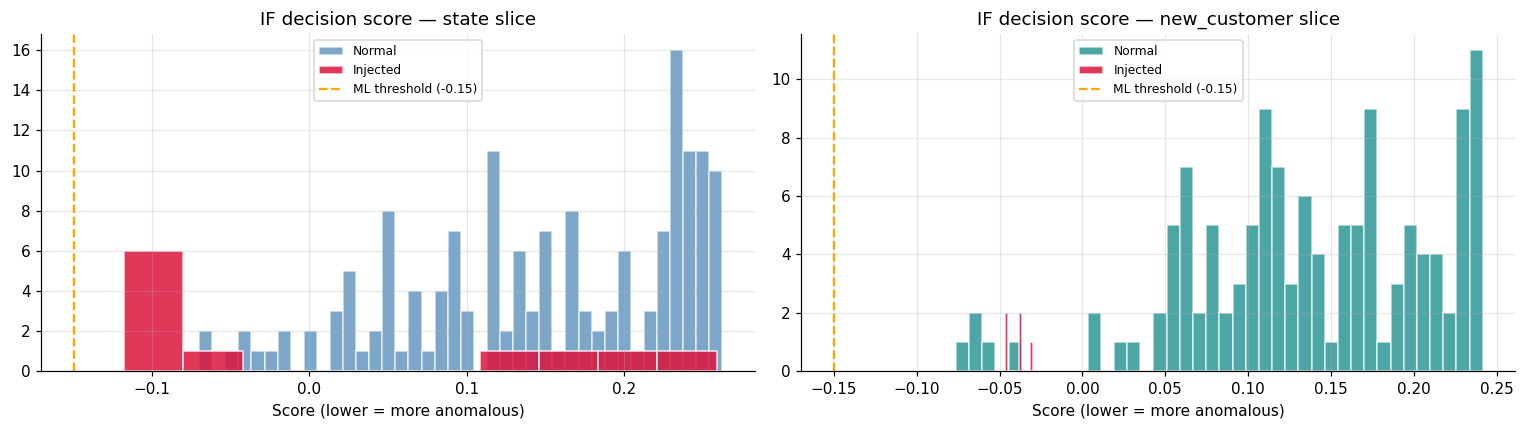

In [ ]:
# IF anomaly score distributions - do injected rows score more anomalous?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, name, color in [(axes[0], 'state', 'steelblue'), (axes[1], 'new_customer', 'teal')]:
    agg = slice_data[name]
    ax.hist(agg.loc[~agg['is_injected'], 'if_score'], bins=40, color=color,   alpha=0.7, label='Normal', edgecolor='white')
    ax.hist(agg.loc[ agg['is_injected'], 'if_score'], bins=10, color='crimson', alpha=0.85, label='Injected', edgecolor='white')
    ax.axvline(ML_THRESH, color='orange', linestyle='--', label=f'ML threshold ({ML_THRESH})')
    ax.set_title(f'IF decision score - {name} slice')
    ax.set_xlabel('Score (lower = more anomalous)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [37]:
# ANOMALY DETECTION

In [38]:
# Two-layer logic:
# Primary signal: both layers agree
# Strong single-layer signal: z-score > HIGH_THRESH OR IF score < ML_THRESH

In [39]:
@dataclass
class AnomalyEvent:
    timestamp: datetime
    group_type: str
    group_value: str
    anomaly_type: str
    severity: str
    current_value: float
    expected_value: float       # seasonal_mean for this (hour_of_day, day_of_week) bucket
    z_score: float
    ml_score: float             # IF decision score (lower = more anomalous)
    detected_by: str            # "both", "statistical", "ml"
    is_injected: bool = False
    anomaly_label: str  = ''


def classify_anomaly_type(row) -> str:
    if abs(row.get('velocity_pct', 0)) > VELOCITY_THRESH:
        return 'velocity_spike' if row['velocity_pct'] > 0 else 'velocity_drop'
    if 'approval_rate_z_score' in row.index and row['approval_rate_z_score'] < -ZSCORE_THRESH:
        return 'approval_rate_drop'
    return 'volume_spike' if row.get('volume_z_score', 0) > 0 else 'volume_drop'



# Score all hourly rows; return AnomalyEvent list
def detect_anomalies(agg: pd.DataFrame, group_type: str, group_value_col=None):
    events = []

    for _, row in agg.iterrows():
        z       = row.get('volume_z_score', 0)
        ar_z    = row.get('approval_rate_z_score', 0)
        vel_pct = row.get('velocity_pct', 0)
        vol     = row.get('volume', 0)

        # Statistical flag: z-score anomaly OR approval-rate crash OR velocity spike
        stat_flag = (
            (abs(z) > ZSCORE_THRESH) or
            (ar_z < -ZSCORE_THRESH) or
            (abs(vel_pct) >= VELOCITY_THRESH and vol >= MIN_VOLUME)
        )

        # ML flag: trust IF's contamination-calibrated threshold directly
        ml_flag = row.get('if_flag', 1) == -1

        if not (stat_flag or ml_flag):
            continue

        detected_by = (
            'both'        if (stat_flag and ml_flag) else
            'statistical' if stat_flag else 'ml'
        )

        # Single-layer statistical: require a high-confidence signal
        if detected_by == 'statistical':
            strong_z   = abs(z) >= HIGH_THRESH
            strong_ar  = ar_z <= -HIGH_THRESH
            strong_vel = abs(vel_pct) >= VELOCITY_THRESH and vol >= MIN_VOLUME
            if not (strong_z or strong_ar or strong_vel):
                continue

        # Skip noisy low-volume buckets for the statistical layer
        if detected_by == 'statistical' and vol < MIN_VOLUME:
            continue

        group_value = str(row[group_value_col]) if group_value_col else 'all'

        events.append(AnomalyEvent(
            timestamp      = row['hour_bucket'],
            group_type     = group_type,
            group_value    = group_value,
            anomaly_type   = classify_anomaly_type(row),
            severity       = 'high' if abs(z) >= 4.0 else 'medium',
            current_value  = round(float(vol), 1),
            expected_value = round(float(row.get('volume_seasonal_mean', 0)), 1),
            z_score        = round(float(z), 2),
            ml_score       = round(float(row.get('if_score', 0)), 4),
            detected_by    = detected_by,
            is_injected    = bool(row.get('is_injected', False)),
            anomaly_label  = str(row.get('anomaly_label', '')),
        ))
    return events

In [40]:
all_events = []
print(f"{'Slice':20s}  {'Events detected':>20}")
print('-' * 40)

for name, cfg in SLICES.items():
    gcol = cfg['group_cols'][0] if cfg['group_cols'] else None
    events = detect_anomalies(slice_data[name], name, gcol)
    all_events.extend(events)
    print(f"{name:20s}  {len(events):>20}")

print(f"{'TOTAL':20s}  {len(all_events):>20}")

Slice                      Events detected
----------------------------------------
overall                                 14
state                                   16
product_type                            22
transaction_status                      12
new_customer                            11
TOTAL                                   75


In [41]:
events_df = pd.DataFrame([vars(e) for e in all_events])

events_df = events_df.sort_values('z_score', key=abs, ascending=False).reset_index(drop=True)
show_cols = ['timestamp', 'group_type', 'group_value', 'anomaly_type', 'severity', 'current_value', 'expected_value', 'z_score', 'ml_score', 'detected_by', 'is_injected', 'anomaly_label']
    
events_df[show_cols].head()

,timestamp,group_type,group_value,anomaly_type,severity,current_value,expected_value,z_score,ml_score,detected_by,is_injected,anomaly_label
0,2024-12-17 14:00:00,state,TX,velocity_spike,high,25.000,1.000,48.000,-0.100,both,True,A1_volume_spike_TX
1,2024-12-17 14:00:00,overall,all,velocity_spike,high,25.000,1.200,47.500,-0.075,both,True,A1_volume_spike_TX
2,2024-12-19 11:00:00,overall,all,velocity_spike,high,20.000,1.200,37.500,-0.074,both,True,A3_volume_spike_new_customers
3,2024-12-18 10:00:00,product_type,mortgage,velocity_spike,high,20.000,1.200,37.500,-0.087,both,True,A2_approval_rate_drop_CA
4,2024-12-17 14:00:00,new_customer,False,velocity_spike,high,19.000,1.000,36.000,-0.047,both,True,A1_volume_spike_TX


In [42]:
# VISUALIZER - PREVIEW
# Time-series of hourly volume with a ±2σ expected range band
# Seasonality mean as a dashed reference line
# Anomaly markers annotated with type and z-score
# 7-day context window centred on the earliest detected anomaly per group

In [ ]:
def plot_anomaly_charts(events, slice_data, slices_cfg, max_panels=6):

    # Rank unique (group_type, group_value) panels by max |z_score|
    seen, panels = set(), []
    for e in sorted(events, key=lambda e: abs(e.z_score), reverse=True):
        key = (e.group_type, e.group_value)
        if key not in seen:
            seen.add(key)
            panels.append(key)
        if len(panels) >= max_panels:
            break

    n = len(panels)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.8 * n), squeeze=False)

    for i, (gtype, gval) in enumerate(panels):
        ax   = axes[i][0]
        agg  = slice_data[gtype]
        gcol = slices_cfg[gtype]['group_cols']
        gcol = gcol[0] if gcol else None

        # Filter to this group
        grp = agg[agg[gcol].astype(str) == gval].copy() if gcol else agg.copy()
        grp = grp.sort_values('hour_bucket')

        # 7-day context window around earliest anomaly in this panel
        panel_events = [e for e in events if e.group_type == gtype and e.group_value == gval]
        if panel_events:
            anchor = min(e.timestamp for e in panel_events)
            w_start = pd.Timestamp(anchor) - timedelta(days=3)
            w_end   = pd.Timestamp(anchor) + timedelta(days=4)
            grp     = grp[(grp['hour_bucket'] >= w_start) & (grp['hour_bucket'] <= w_end)]

        if grp.empty:
            ax.set_title(f'{gtype} = {gval}  (no data in window)')
            continue

        # Volume time-series
        ax.plot(grp['hour_bucket'], grp['volume'],
                color='steelblue', linewidth=1.3, label='Volume', zorder=2)

        # Seasonal mean + ±2σ band
        if 'volume_seasonal_mean' in grp.columns:
            m = grp['volume_seasonal_mean']
            s = grp['volume_seasonal_std']
            ax.plot(grp['hour_bucket'], m,
                    color='steelblue', linewidth=0.9, linestyle='--',
                    alpha=0.55, label='Seasonal mean')
            ax.fill_between(grp['hour_bucket'],
                            (m - 2 * s).clip(0), m + 2 * s,
                            alpha=0.12, color='steelblue', label='±2σ expected')

        # Anomaly markers
        already_labelled = set()
        for e in panel_events:
            pt = grp[grp['hour_bucket'] == pd.Timestamp(e.timestamp)]
            if pt.empty:
                continue
            x_val = pt['hour_bucket'].values[0]
            y_val = pt['volume'].values[0]
            ax.scatter(x_val, y_val, color='crimson', s=100, zorder=5)
            label_key = (e.anomaly_type, round(e.z_score, 0))
            if label_key not in already_labelled:
                ax.annotate(
                    f"{e.anomaly_type}\nz={e.z_score:+.1f}  [{e.detected_by}]",
                    xy=(x_val, y_val),
                    xytext=(14, 8), textcoords='offset points',
                    fontsize=7.5, color='crimson',
                    arrowprops=dict(arrowstyle='->', color='crimson', lw=0.8),
                )
                already_labelled.add(label_key)

        badge = ' INJECTED' if any(e.is_injected for e in panel_events) else ''
        ax.set_title(f'{gtype} = {gval}{badge}', fontsize=10, fontweight='bold')
        ax.set_ylabel('Transactions / hr', fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:00'))
        ax.tick_params(axis='x', labelsize=7)
        if i == 0:
            ax.legend(fontsize=7.5, loc='upper left')

    axes[-1][0].set_xlabel('Hour bucket', fontsize=9)
    plt.suptitle(
        'Anomaly Detection - Hourly volume with seasonality baseline',
        fontsize=11, fontweight='bold', y=1.005,
    )
    plt.tight_layout()
    plt.show()


print('Visualizer defined.')

Visualizer defined.


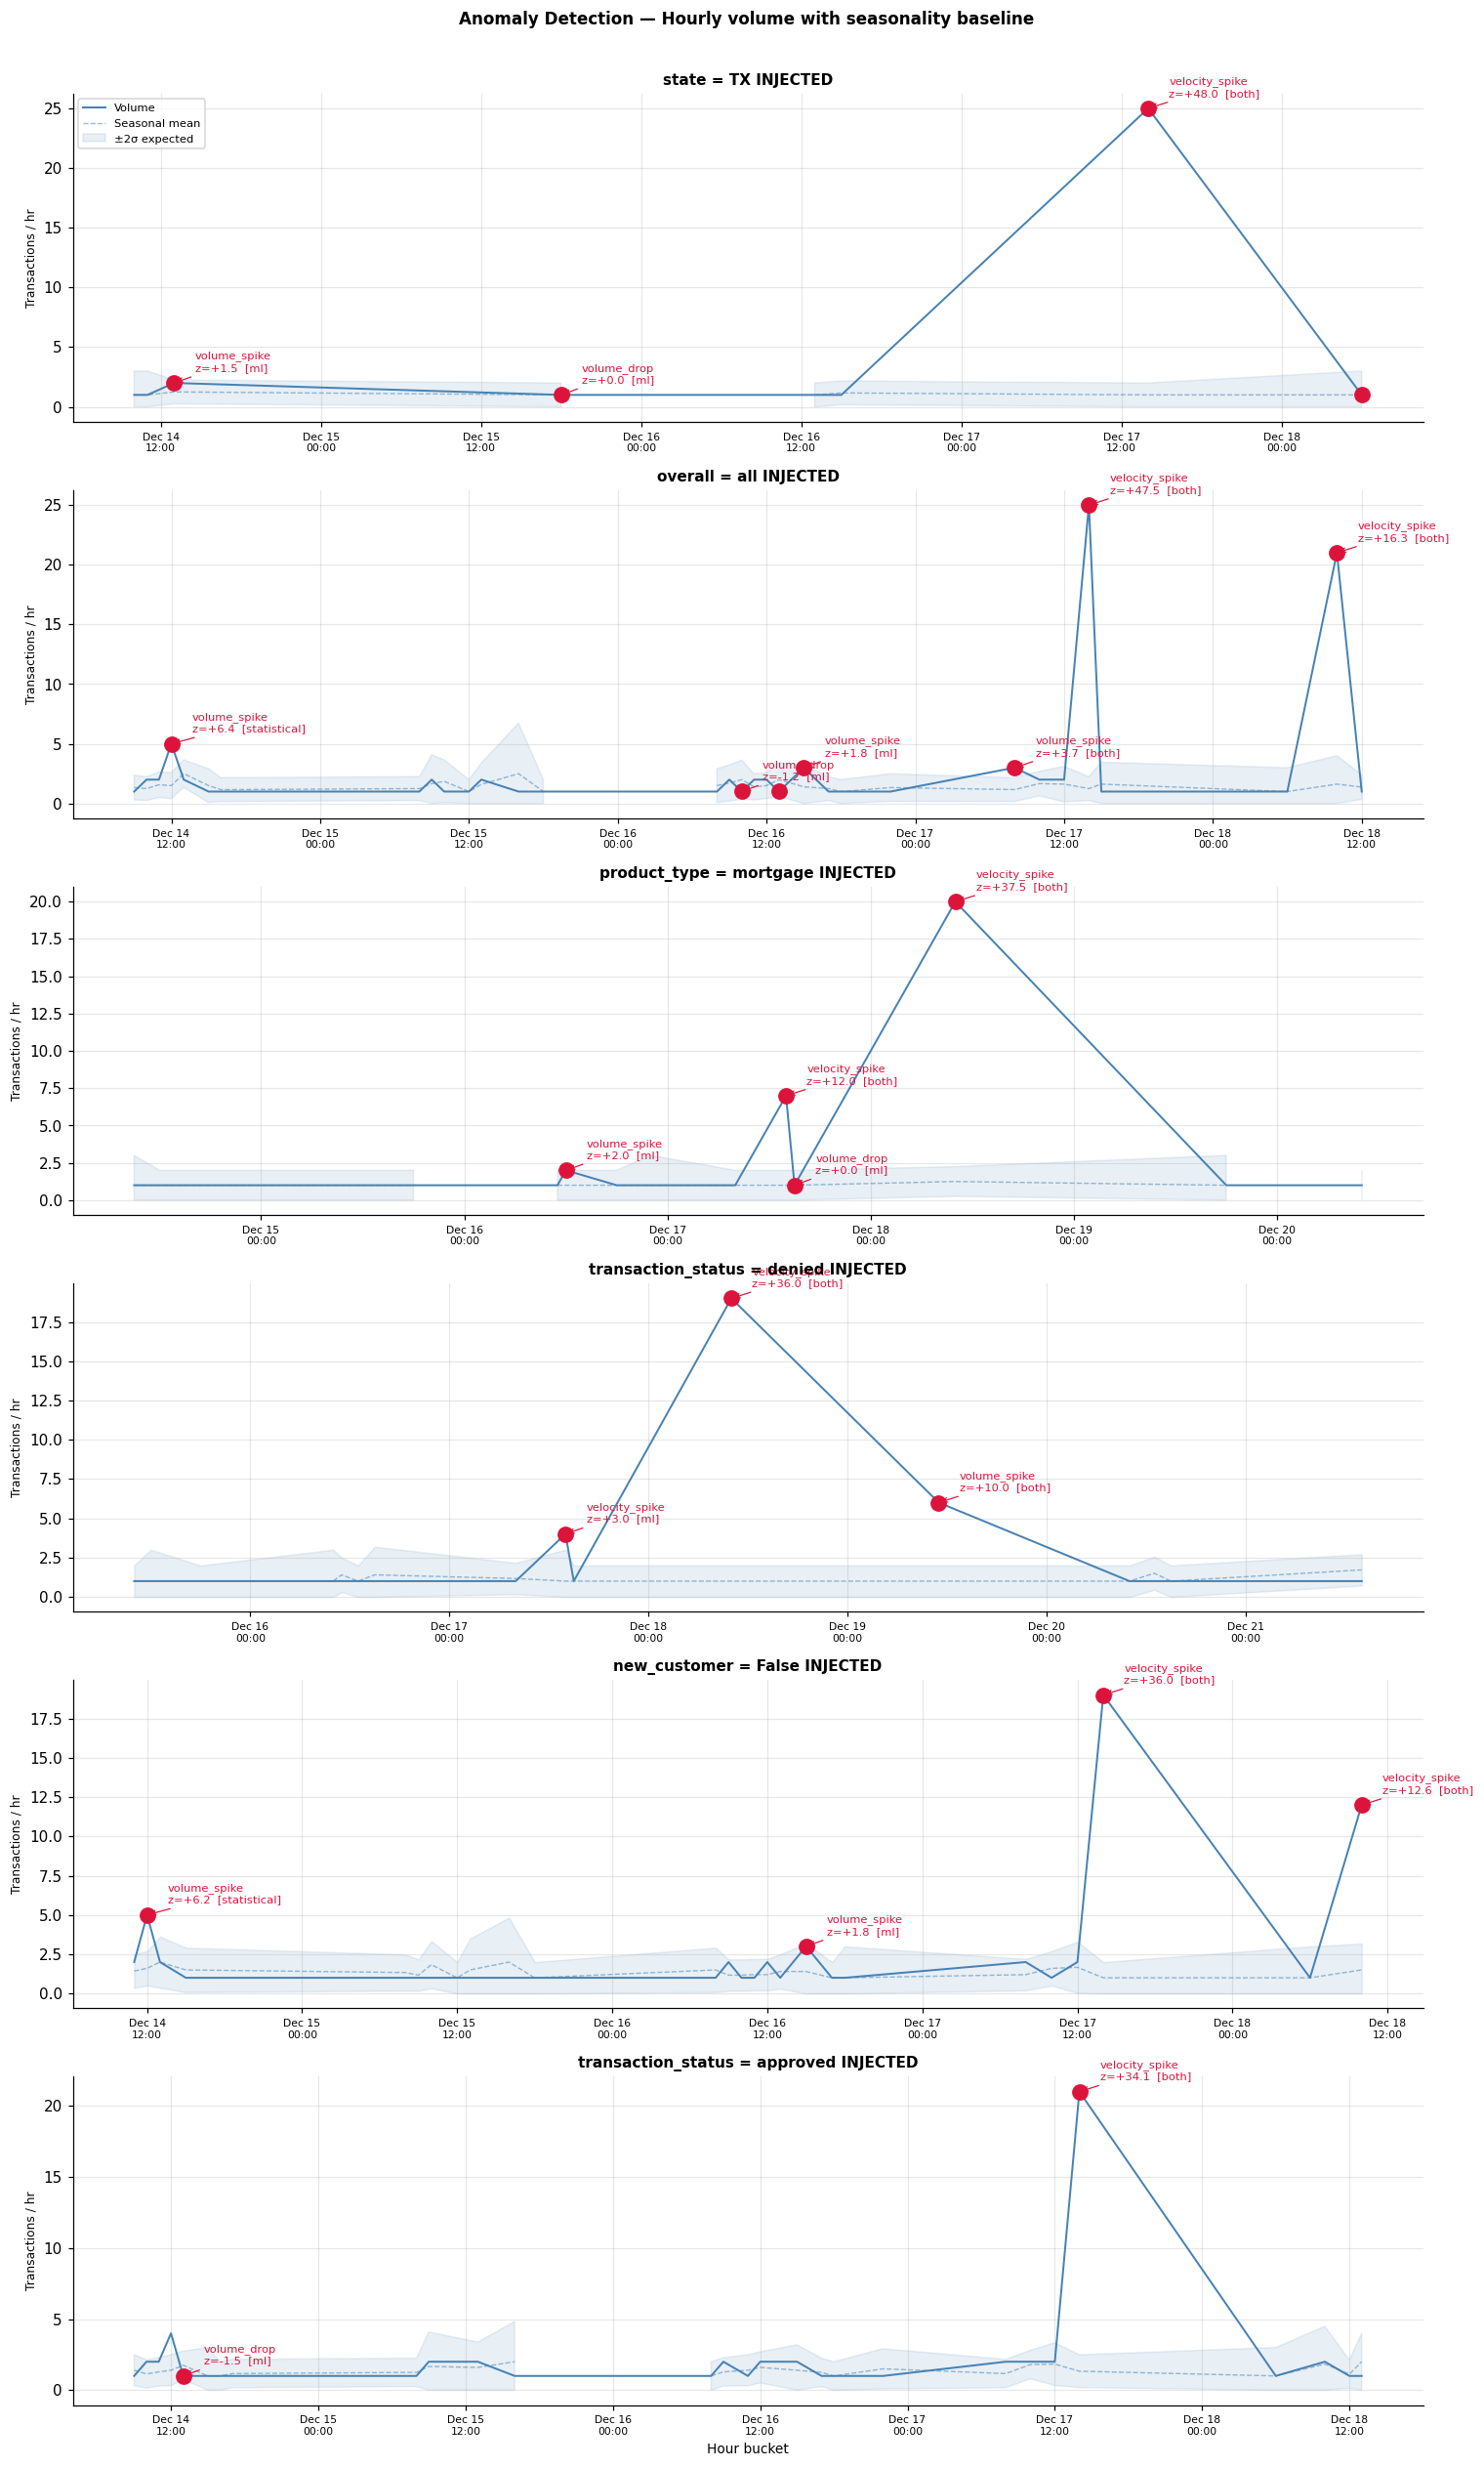

In [44]:
plot_anomaly_charts(all_events, slice_data, SLICES, max_panels=6)

In [45]:
# EVALUATE
# Capture, accuracy

In [46]:
GROUND_TRUTH = {
    'A1': {'group_type': 'state',        
           'group_value': 'TX',
           'timestamp': pd.Timestamp('2024-12-17 14:00:00'),
           'expected_type': 'volume_spike'
           },
    'A2': {'group_type': 'state',        
           'group_value': 'CA',
           'timestamp': pd.Timestamp('2024-12-18 10:00:00'),
           'expected_type': 'approval_rate_drop'
           },
    'A3': {'group_type': 'new_customer', 
           'group_value': 'True',
           'timestamp': pd.Timestamp('2024-12-19 11:00:00'),
           'expected_type': 'volume_spike'
           },
}


print('Ground-Truth Recall:\n')
print(f'{"ID":<5} {"Slice":30} {"Hour":25} {"Detected?":<10} {"Details"}')
print('-' * 100)


detected_ids = set()
for aid, gt in GROUND_TRUTH.items():
    hits = [
        e for e in all_events
        if  e.group_type  == gt['group_type']
        and e.group_value == gt['group_value']
        and pd.Timestamp(e.timestamp) == gt['timestamp']
    ]
    found = bool(hits)
    if found:
        detected_ids.add(aid)
        h = hits[0]
        detail = (f"type={h.anomaly_type}  z={h.z_score:+.2f}  "
                  f"ml={h.ml_score:.4f}  by={h.detected_by}  sev={h.severity}")
    else:
        detail = 'NOT DETECTED'
    label = f"{gt['group_type']}={gt['group_value']}"
    tick  = 'Y' if found else 'N'
    print(f"{aid:<5} {label:30} {str(gt['timestamp']):<25} {tick:<10} {detail}")


recall = len(detected_ids) / len(GROUND_TRUTH)



print(f"\nRecall : {recall:.0%}  ({len(detected_ids)}/{len(GROUND_TRUTH)} injected anomalies found)")
print(f"Total events surfaced across all slices: {len(all_events)}")

Ground-Truth Recall:

ID    Slice                          Hour                      Detected?  Details
----------------------------------------------------------------------------------------------------
A1    state=TX                       2024-12-17 14:00:00       Y          type=velocity_spike  z=+48.00  ml=-0.0995  by=both  sev=high
A2    state=CA                       2024-12-18 10:00:00       Y          type=velocity_spike  z=+19.00  ml=-0.1178  by=both  sev=high
A3    new_customer=True              2024-12-19 11:00:00       Y          type=velocity_spike  z=+19.00  ml=-0.0299  by=both  sev=high

Recall : 100%  (3/3 injected anomalies found)
Total events surfaced across all slices: 75


In [47]:
# Closer look: approval-rate signal for A2
print('A2 Approval-Rate Deep-Dive (state=CA):\n')

ca = slice_data['state']
ca_row = ca[
    (ca['state'] == 'CA') &
    (ca['hour_bucket'] == pd.Timestamp('2024-12-18 10:00:00'))
]


r = ca_row.iloc[0]

print(f"hour_bucket: {r['hour_bucket']}")
print(f"volume: {r['volume']}")
print(f"n_approved: {r['n_approved']}")
print(f"approval_rate: {r['approval_rate']:.3f}")

if 'approval_rate_seasonal_mean' in r.index:
    print(f"approval_rate seasonal_mean: {r['approval_rate_seasonal_mean']:.3f}")
    print(f"approval_rate z_score: {r.get('approval_rate_z_score', float('nan')):.2f}")

print(f"volume_z_score: {r['volume_z_score']:.2f}")
print(f"velocity_pct: {r['velocity_pct']:.2f}")
print(f"if_score: {r['if_score']:.4f}  (flag={r['if_flag']})")
print(f"is_injected: {r['is_injected']}")

# All A2-related events in the detected list
a2_events = [
    e for e in all_events
    if 'A2' in e.anomaly_label or
       (e.group_type == 'state' and e.group_value == 'CA'
        and pd.Timestamp(e.timestamp) == pd.Timestamp('2024-12-18 10:00:00'))
]

print(f"\n  A2-related events detected: {len(a2_events)}")

for e in a2_events:
    print(f"    {e}")

A2 Approval-Rate Deep-Dive (state=CA):

hour_bucket: 2024-12-18 10:00:00
volume: 20
n_approved: 2
approval_rate: 0.100
approval_rate seasonal_mean: 1.000
approval_rate z_score: -0.90
volume_z_score: 19.00
velocity_pct: 5.00
if_score: -0.1178  (flag=-1)
is_injected: True

  A2-related events detected: 6
    AnomalyEvent(timestamp=Timestamp('2024-12-18 10:00:00'), group_type='overall', group_value='all', anomaly_type='velocity_spike', severity='high', current_value=21.0, expected_value=1.6, z_score=16.31, ml_score=-0.1024, detected_by='both', is_injected=True, anomaly_label='A2_approval_rate_drop_CA')
    AnomalyEvent(timestamp=Timestamp('2024-12-18 10:00:00'), group_type='state', group_value='CA', anomaly_type='velocity_spike', severity='high', current_value=20.0, expected_value=1.0, z_score=19.0, ml_score=-0.1178, detected_by='both', is_injected=True, anomaly_label='A2_approval_rate_drop_CA')
    AnomalyEvent(timestamp=Timestamp('2024-12-18 10:00:00'), group_type='product_type', group_

In [ ]:
# NOTES

# Injected anomalies are dense relative to the background:
# A1 - TX 2024-12-17 14:00: 25 injected rows into an otherwise sparse background.
#        volume_z_score should be strongly positive; velocity_pct clamped at 5.0.
# A2 - CA 2024-12-18 10:00: 20 rows with 80% denied.  approval_rate_z_score
#        should be strongly negative; IF should also flag the unusual feature combo.
# A3 - new_customer=True 2024-12-19 11:00: 20 injected new-customer rows.
#        volume_z_score and velocity_pct are primary detection signals.

# At production volume, seasonal buckets well-populated, z-scores stable, and both false-positive and false-negative rates decrease.